# Alex Notebook

In [1]:
from pathlib import Path
Path("alex").mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=33)
n = 800

course_track = rng.choice(["Web Dev", "Data Science", "Design"], size=n, p=[0.36, 0.32, 0.32])
weekly_login_hours = rng.normal(6, 2.5, size=n).clip(0, None).round(1)
forum_posts = rng.normal(4, 3, size=n).clip(0, None).round(0)
noise = rng.normal(0, 12, size=n)
track_bonus = pd.Series(course_track).map({"Web Dev": 0, "Design": 0, "Data Science": 6}).values
completion_pct = (20 + 8.5*weekly_login_hours + track_bonus + noise).clip(0, 100).round(1)

learners = pd.DataFrame({
    "learner_id": np.arange(1, n + 1),
    "course_track": course_track,
    "weekly_login_hours": weekly_login_hours,
    "forum_posts": forum_posts,
    "completion_pct": completion_pct,
})

## Alex's markdown cell — "Distribution of Weekly Login Hours":

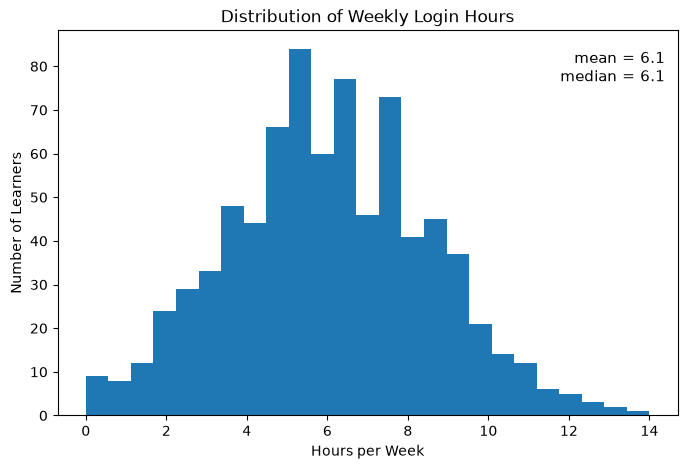

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(learners["weekly_login_hours"], bins=25)
ax.set_title("Distribution of Weekly Login Hours")
ax.set_xlabel("Hours per Week")
ax.set_ylabel("Number of Learners")
ax.annotate(
    f"mean = {learners['weekly_login_hours'].mean():.1f}\nmedian = {learners['weekly_login_hours'].median():.1f}",
    xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=11,
)
fig.savefig("alex/chart_distribution.png")

## Alex's markdown cell — "Relationship: Course Track and Completion":

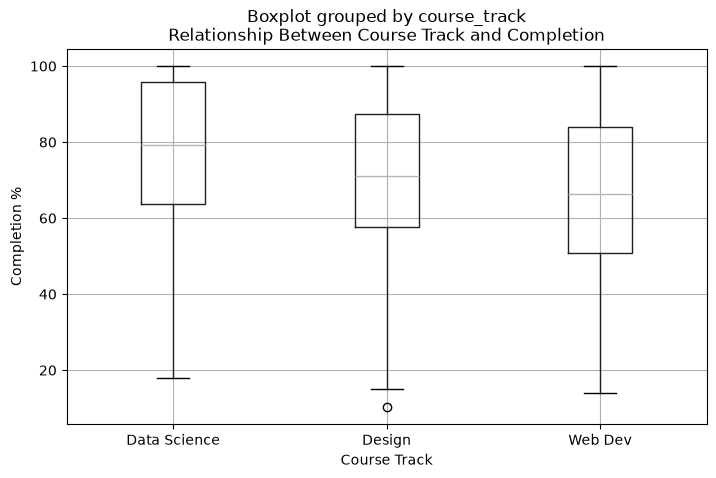

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
order = learners.groupby("course_track")["completion_pct"].mean().sort_values(ascending=False).index
colors = {"Data Science": "green", "Design": "yellow", "Web Dev": "red"}
learners.boxplot(column="completion_pct", by="course_track", ax=ax,
                  positions=range(len(order)))
ax.set_title("Relationship Between Course Track and Completion")
ax.set_xlabel("Course Track")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_relationship_track.png")

## Alex's markdown cell — "Login Hours and Completion":

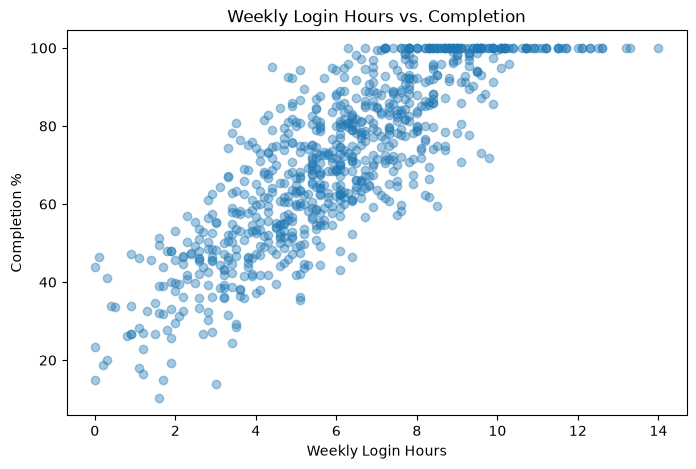

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(learners["weekly_login_hours"], learners["completion_pct"], alpha=0.4)
ax.set_title("Weekly Login Hours vs. Completion")
ax.set_xlabel("Weekly Login Hours")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_login_vs_completion.png")
plt.show()

## Alex's markdown cell — "Forum Activity":

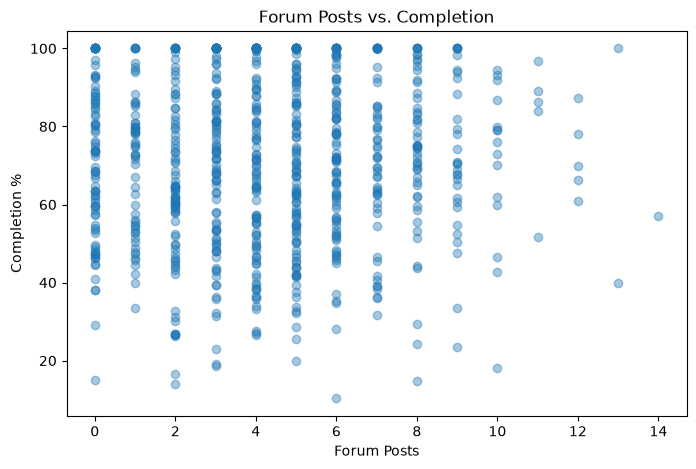

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(learners["forum_posts"], learners["completion_pct"], alpha=0.4)
ax.set_title("Forum Posts vs. Completion")
ax.set_xlabel("Forum Posts")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_forum_vs_completion.png")
plt.show()

## Alex's markdown cell — "Findings":

1. Weekly login hours cause higher completion — the platform should nudge learners to log in more.
2. Data Science learners have noticeably higher completion than the other two tracks.
3. The average completion rate across all learners is approximately 74%.

## Alex's markdown cell — "Conclusion": 

"This analysis shows that increasing login frequency is the clearest lever for improving course completion, and that course design differences between tracks are a secondary factor worth investigating."

In [7]:
print("-"*50 +"#"*50 + "-"*50)

--------------------------------------------------##################################################--------------------------------------------------


# Week 06 · Tue · Practice — EDA Peer Review Lab
## Finding the Mistakes in Someone Else's Analysis

This notebook has three parts, matching today's build task:

- **Part A** — Alex's notebook reproduced exactly, then a structured written review against the 8-point checklist.
- **Part B** — the corrected notebook: every issue fixed, rebuilt from the same `learners` DataFrame.
- **Part C** — a short reviewer's note.

A separate `review.md` and `reviewer_note.md` accompany this notebook with the same
written content in plain markdown.

# Part A: Peer Review Checklist & Issue Breakdown

In [8]:
from IPython.display import Markdown

Markdown(open("review.md").read())

# Alex's Notebook — Peer Review

## Week 06 · Tuesday · EDA Peer Review Lab

### Review objective

This review evaluates Alex's EDA notebook against the eight-point pre-submission checklist. The goal is to identify analysis, interpretation, visualization, and reporting issues before the work is treated as a finished analysis.

The dataset setup is correct and is reproduced without modification. The issues below concern the analysis built on top of the `learners` DataFrame.

---

# Part A — Structured Review

## Issue 1 — Course Track is mislabeled as a relationship

**Checklist item:** 1 — Distinguish a genuine relationship chart from a categorical comparison.

**Location:** Course Track chart, cells containing:

```python
order = learners.groupby("course_track")["completion_pct"].mean().sort_values(ascending=False).index
learners.boxplot(
    column="completion_pct",
    by="course_track",
    ax=ax,
    positions=range(len(order))
)
ax.set_title("Relationship Between Course Track and Completion")
```

**Problem:**

`course_track` is a categorical variable with three groups:

- Web Dev
- Data Science
- Design

`completion_pct` is a continuous variable.

Therefore, this chart compares the distribution of completion percentages across categories. It is not a relationship chart between two continuous variables.

**Evidence:**

The x-axis contains course-track categories while the y-axis contains completion percentage. The chart is therefore a group comparison.

**Shuffle-test justification:**

If the `course_track` labels were randomly shuffled among learners, the group assignments would be destroyed and the observed group differences would generally disappear. This indicates that the analysis is comparing categories rather than examining two continuously varying variables.

**Required correction:**

Rename the chart:

```text
Course Completion by Course Track
```

and describe the result as a **categorical comparison**, not a relationship.

**Correct wording:**

> Data Science learners have higher completion than Web Dev and Design learners in this sample.

---

## Issue 2 — Login-hours correlation is described but not quantified

**Checklist item:** 2 — Every correlation should be computed and reported as a number.

**Location:** `Login Hours and Completion` chart and Alex's note.

Alex's chart is:

```python
ax.scatter(
    learners["weekly_login_hours"],
    learners["completion_pct"],
    alpha=0.4
)
```

Alex then writes:

> "There's a strong, obvious upward relationship..."

**Problem:**

The scatterplot is appropriate for examining two numeric variables, but Alex does not calculate or report a correlation coefficient.

A visual impression such as "strong" is not enough when a correlation is being discussed.

**Fresh computation:**

The Pearson correlation is:

```text
r = 0.838
```

**Correct interpretation:**

> Weekly login hours and completion have a strong positive linear correlation (Pearson r = 0.838).

The numerical value should appear in the analysis rather than relying only on visual description.

---

## Issue 3 — Correlation is incorrectly presented as causation

**Checklist item:** 4 — Causal language must not be used without appropriate evidence.

**Location:** Alex's note under `Login Hours and Completion` and the Findings/Conclusion sections.

Alex writes:

> "There's a strong, obvious upward relationship — more login hours clearly causes higher completion."

and:

> "Platforms should push learners to log in more often to drive completion up."

The conclusion similarly states:

> "This analysis shows that increasing login frequency is the clearest lever for improving course completion..."

**Problem:**

The analysis is observational. A strong correlation does not establish that increasing login hours will cause completion to increase.

The Pearson correlation of `r = 0.838` establishes a strong positive association, but it does not establish the direction of causality.

**Plausible confound:**

Learner motivation could influence both variables:

```text
              Learner motivation
                 /         \
                ↓           ↓
       More login hours   Higher completion
```

A highly motivated learner may log in more and also be more likely to finish the course.

**Required correction:**

Replace causal language such as:

- causes
- drive
- increasing ... improves
- lever for improving

with appropriately scoped correlational language.

**Correct wording:**

> Weekly login hours are strongly positively correlated with completion (Pearson r = 0.838), but this observational analysis does not establish causation. Learner motivation is a plausible confound that could influence both login activity and completion.

---

## Issue 4 — Forum-post result is omitted from the findings

**Checklist item:** 3 — Every chart result, including a null result, should appear in the written findings.

**Location:** `Forum Activity` chart.

Alex creates:

```python
ax.scatter(
    learners["forum_posts"],
    learners["completion_pct"],
    alpha=0.4
)
```

but provides no written interpretation before moving to the Findings section.

**Problem:**

The chart represents a separate analysis question, but its result is completely absent from the written findings.

This is particularly important because the result is essentially null. A null result is still a result and should not be omitted simply because it is less interesting than the other findings.

**Fresh computation:**

The Pearson correlation is:

```text
r = 0.039
```

**Correct interpretation:**

> Forum-post count has essentially no linear correlation with course completion (Pearson r = 0.039).

This finding should be explicitly included in the Findings section.

---

## Issue 5 — Course-track ordering is based on the result rather than a deliberate fixed order

**Checklist item:** 5 — Category ordering should be deliberate and justified.

**Location:**

```python
order = learners.groupby("course_track")["completion_pct"].mean().sort_values(ascending=False).index
```

**Problem:**

Alex sorts the categories according to their observed completion means.

This means the category order is determined by the result of the analysis rather than by a stable, deliberate ordering.

The current order is approximately:

```text
Data Science
Design
Web Dev
```

If the underlying data changes, the order can also change.

This makes it harder to consistently locate a category such as `Design` across different versions of the chart.

There is also a technical concern: the calculated `order` is passed only to `positions`; it does not explicitly reorder the category data itself. Therefore, the intended category order is not robustly established by the code.

**Required correction:**

Define an explicit fixed order:

```python
track_order = [
    "Web Dev",
    "Data Science",
    "Design"
]
```

Then explicitly apply that order to the visualization.

**Correct principle:**

The ordering should be chosen because it is meaningful and stable, not because it makes the observed result appear ranked.

---

## Issue 6 — Color choice is not deliberate and the defined colors are not actually used

**Checklist item:** 5 — Colors should be deliberate and justified.

**Location:**

```python
colors = {
    "Data Science": "green",
    "Design": "yellow",
    "Web Dev": "red"
}
```

**Problem:**

Alex defines three colors, but the `colors` variable is never passed into the boxplot.

Therefore, the intended colors do not actually control the chart.

Additionally, assigning arbitrary colors such as red, yellow, and green could unintentionally imply a qualitative judgment such as bad/warning/good when no such meaning exists in the analysis.

**Required correction:**

Use a single deliberate color for the boxplot, or use a multi-color scheme only if each color has a clearly justified meaning.

For this analysis, a single color is preferable because the purpose is simply to compare the distributions across tracks.

**Correct principle:**

> Color should communicate information or remain neutral; it should not introduce an unsupported interpretation.

---

## Issue 7 — Histogram annotation/layout needs visual QA

**Checklist item:** 6 — Saved charts must be opened and checked for layout problems.

**Location:** `Distribution of Weekly Login Hours`.

Alex uses:

```python
ax.annotate(
    f"mean = {learners['weekly_login_hours'].mean():.1f}\nmedian = {learners['weekly_login_hours'].median():.1f}",
    xy=(0.98, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=11,
)
```

**Problem:**

At the specified figure size, the annotation is positioned very close to the upper-right of the axes and overlaps the title/layout when the saved PNG is inspected.

The important issue is not whether the Python code executes successfully. The saved chart itself must be visually inspected.

**Required correction:**

Move the annotation lower within the axes and apply a layout adjustment:

```python
xy=(0.98, 0.82)
```

and:

```python
fig.tight_layout()
```

The resulting PNG should then be opened and visually checked to confirm that the title, annotation, axes, and plot area do not overlap.

**Correct principle:**

> A chart is not considered finished merely because the plotting code runs without an error. The actual saved image must be inspected.

---

## Issue 8 — The reported overall mean is incorrect

**Checklist item:** 7 — Written numbers must match a fresh computation.

**Location:** Findings item #3.

Alex writes:

> "The average completion rate across all learners is approximately 74%."

**Problem:**

A fresh computation of:

```python
learners["completion_pct"].mean()
```

gives:

```text
71.16%
```

or approximately:

```text
71.2%
```

Therefore, Alex's stated value of approximately 74% does not match the dataset.

**Correct wording:**

> The overall mean completion percentage is 71.16% (approximately 71.2%).

The original `~74%` claim should be removed.

---

## Issue 9 — Course-track difference needs statistical uncertainty

**Checklist item:** 8 — A claimed group difference should have statistical backing rather than relying only on a visual impression.

**Location:** Findings item #2 and the course-track boxplot.

Alex writes:

> "Data Science learners have noticeably higher completion than the other two tracks."

**Problem:**

The boxplot provides useful descriptive evidence, but the statement that the difference is meaningful should be supported with uncertainty rather than relying only on visual separation.

The relevant means are:

| Course Track | Mean Completion |
|---|---:|
| Web Dev | 66.96% |
| Data Science | 76.78% |
| Design | 70.69% |

The observed Data Science − Web Dev difference is:

```text
9.82 percentage points
```

**Bootstrap analysis:**

A bootstrap 95% confidence interval for the Data Science − Web Dev completion gap is approximately:

```text
6.34 to 13.26 percentage points
```

**Interpretation:**

Zero is not included in this confidence interval.

Therefore, the bootstrap result supports the existence of a difference between the Data Science and Web Dev groups in this sample.

**Correct wording:**

> Data Science learners have an observed mean completion rate 9.82 percentage points higher than Web Dev learners. A bootstrap 95% confidence interval for this gap is approximately 6.34–13.26 percentage points, which excludes zero and supports a difference between the groups in this sample.

This should still not be interpreted as evidence that being enrolled in the Data Science track causes higher completion.

---

# Numerical Audit Summary

The following values were independently recomputed from the `learners` DataFrame:

| Metric | Verified Result |
|---|---:|
| Overall mean completion | **71.16%** |
| Pearson r: Login Hours vs Completion | **0.838** |
| Pearson r: Forum Posts vs Completion | **0.039** |
| Web Dev mean completion | **66.96%** |
| Data Science mean completion | **76.78%** |
| Design mean completion | **70.69%** |
| Data Science − Web Dev gap | **9.82 percentage points** |
| Bootstrap 95% CI | **6.34 to 13.26 percentage points** |
| Does CI include zero? | **No** |

---

# Review Checklist Coverage

| Checklist | Result | Main Issue |
|---|---|---|
| 1. Relationship vs comparison | ❌ | Course Track is a categorical comparison |
| 2. Correlation reported numerically | ❌ | Login-hours correlation was not reported |
| 3. Every result reported | ❌ | Forum-post result was omitted |
| 4. Causal language controlled | ❌ | Login hours incorrectly described as causing completion |
| 5. Colors/order deliberate | ❌ | Track order is result-based and colors are unused/arbitrary |
| 6. Saved charts visually checked | ❌ | Histogram annotation/layout needs correction |
| 7. Numbers independently verified | ❌ | 74% claim is incorrect; actual mean is 71.16% |
| 8. Comparison statistically supported | ❌ | Data Science vs Web Dev needs uncertainty; bootstrap CI added |

---

# Part C — Reviewer's Note

The original analysis has a good foundation: the scatterplots are appropriate for examining the relationships between the numeric variables, and the course-track comparison is a useful question to investigate. The highest-priority issue is the causal language around login hours, because the observational correlation does not establish that increasing login frequency will cause higher completion. The numerical audit also identified an incorrect overall mean and a missing null result for forum activity, while the course-track comparison needs deliberate ordering and statistical uncertainty. After these corrections, the analysis will communicate its evidence much more accurately and defensibly.

# Part B: Corrected Python Code & Analysis

---
# Setup

This part is correct in Alex's original — reproduced exactly, unmodified.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=33)
n = 800

course_track = rng.choice(["Web Dev", "Data Science", "Design"], size=n, p=[0.36, 0.32, 0.32])
weekly_login_hours = rng.normal(6, 2.5, size=n).clip(0, None).round(1)
forum_posts = rng.normal(4, 3, size=n).clip(0, None).round(0)
noise = rng.normal(0, 12, size=n)
track_bonus = pd.Series(course_track).map({"Web Dev": 0, "Design": 0, "Data Science": 6}).values
completion_pct = (20 + 8.5*weekly_login_hours + track_bonus + noise).clip(0, 100).round(1)

learners = pd.DataFrame({
    "learner_id": np.arange(1, n + 1),
    "course_track": course_track,
    "weekly_login_hours": weekly_login_hours,
    "forum_posts": forum_posts,
    "completion_pct": completion_pct,
})

learners.head()

,learner_id,course_track,weekly_login_hours,forum_posts,completion_pct
0,1,Data Science,8.4,9.0,94.5
1,2,Data Science,8.0,3.0,83.3
2,3,Design,8.4,3.0,100.0
3,4,Web Dev,7.9,1.0,78.1
4,5,Data Science,4.9,6.0,70.9


In [10]:
learners.describe()

,learner_id,weekly_login_hours,forum_posts,completion_pct
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,6.072125,4.255000,71.160375
std,231.0844,2.489902,2.796382,21.024601
min,1.0000,0.000000,0.000000,10.300000
25%,200.7500,4.400000,2.000000,55.500000
50%,400.5000,6.100000,4.000000,72.100000
75%,600.2500,7.800000,6.000000,88.600000
max,800.0000,14.000000,14.000000,100.000000


In [11]:
learners.shape

(800, 5)

In [12]:
learners.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   learner_id          800 non-null    int64  
 1   course_track        800 non-null    str    
 2   weekly_login_hours  800 non-null    float64
 3   forum_posts         800 non-null    float64
 4   completion_pct      800 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 31.4 KB


In [13]:
print("Learners ------- Missing Values")
learners.isna().sum()

Learners ------- Missing Values


learner_id            0
course_track          0
weekly_login_hours    0
forum_posts           0
completion_pct        0
dtype: int64

In [14]:
learners.duplicated().sum()

np.int64(0)

In [15]:
learners["course_track"].value_counts()

course_track
Web Dev         307
Data Science    250
Design          243
Name: count, dtype: int64

### Fix 1,5 & 6 — Course-track chart reclassified as a comparison, deliberate color, consistent order

In [16]:
Path("fixed").mkdir(parents=True, exist_ok=True)

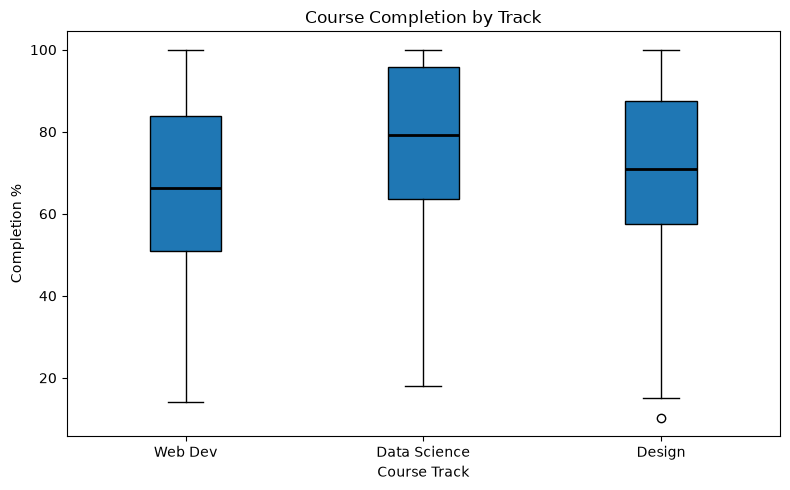

Shuffle-test note: course_track contains three discrete categories, so this is a categorical group comparison rather than a relationship between two continuous variables.
If course_track labels were randomly shuffled among learners, the observed group differences would be disrupted, confirming that the chart represents a comparison of groups.


In [17]:
# track_order = sorted(learners["course_track"].unique())
track_order = ["Web Dev", "Data Science", "Design"]

fig, ax = plt.subplots(figsize=(8, 5))
data_by_track = [learners.loc[learners.course_track == t, "completion_pct"] for t in track_order]
ax.boxplot(data_by_track, tick_labels=track_order, patch_artist=True, medianprops=dict( color="black",linewidth=2))
ax.set_title("Course Completion by Track")
ax.set_xlabel("Course Track")
ax.set_ylabel("Completion %")
fig.tight_layout()
fig.savefig("fixed/fixed_chart_track_comparison.png", dpi=150)
plt.show()

print(
    "Shuffle-test note: course_track contains three discrete categories, "
    "so this is a categorical group comparison rather than a relationship "
    "between two continuous variables."
)
print(
    "If course_track labels were randomly shuffled among learners, the "
    "observed group differences would be disrupted, confirming that the "
    "chart represents a comparison of groups."
)

### Fix 2 — Actual Pearson correlation for login hours vs. completion

In [18]:
r_login, p_login = stats.pearsonr(learners["weekly_login_hours"], learners["completion_pct"])
print(f"Pearson r (weekly login hours vs. completion) = {r_login:.3f}, p = {p_login:.3g}, n = {len(learners)}")

Pearson r (weekly login hours vs. completion) = 0.838, p = 3.02e-212, n = 800


## Fix 3 — Login-hours finding rewritten as a correlational claim, with a named confound

> **Corrected finding:** Weekly login hours are **strongly correlated** with completion
> (Pearson r ≈ 0.838, p ≈ 3.0e-212) — but correlation is not causation. A plausible confound: more
> self-motivated or time-available learners likely both log in more *and* are more likely to finish
> the course, regardless of whether the login hours themselves have any causal effect on completion.
> The data alone can't rule this out, so "log in more to finish more" is not a claim this chart supports.

### Fix 4 — Forum-posts null result brought into the findings

In [19]:
r_forum, p_forum = stats.pearsonr(learners["forum_posts"], learners["completion_pct"])
print(f"Pearson r (forum posts vs. completion) = {r_forum:.3f}, p = {p_forum:.3g}")
print("-> This is a null result: essentially no linear relationship, and not statistically significant.")

Pearson r (forum posts vs. completion) = 0.039, p = 0.27
-> This is a null result: essentially no linear relationship, and not statistically significant.


### Fix 7 — Histogram layout bug fixed and verified against the saved PNG

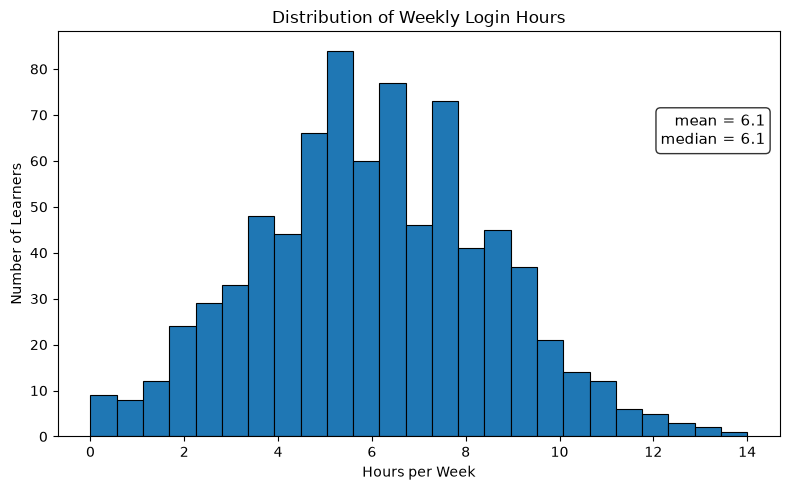

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(learners["weekly_login_hours"], bins=25, edgecolor="black", linewidth=0.8)
ax.set_title("Distribution of Weekly Login Hours")
ax.set_xlabel("Hours per Week")
ax.set_ylabel("Number of Learners")
# Moved out of the top-right corner (where it overlapped the title) and into a clear area of the plot.
ax.annotate(
    f"mean = {learners['weekly_login_hours'].mean():.1f}\nmedian = {learners['weekly_login_hours'].median():.1f}",
    xy=(0.98, 0.80), xycoords="axes fraction", ha="right", va="top", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
fig.tight_layout()
fig.savefig("fixed/fixed_chart_distribution.png")
plt.show()

Saved PNG size: (800, 500)


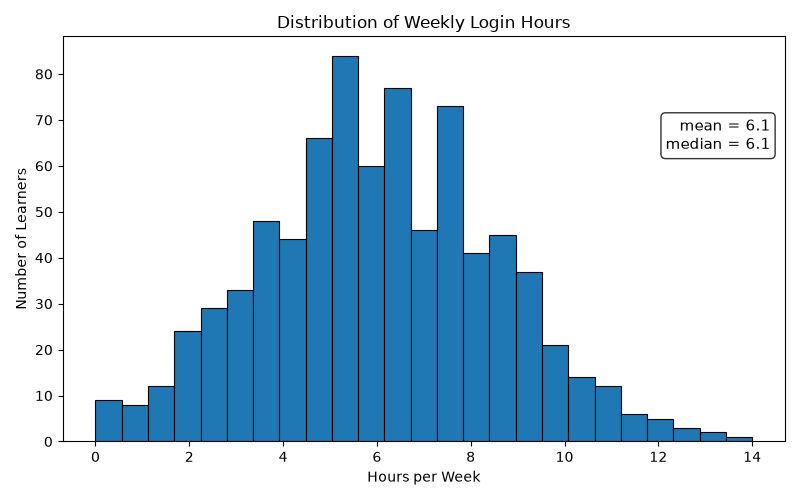

In [21]:
# Verify by actually opening the saved PNG file (not just trusting the inline render)
from PIL import Image
img = Image.open("fixed/fixed_chart_distribution.png")
print("Saved PNG size:", img.size)
img

### Fix 8 — Recomputed mean completion vs. Alex's "approximately 74%" claim

In [22]:
actual_mean = learners["completion_pct"].mean()
print(f"Fresh computation: mean completion = {actual_mean:.2f}%")
print(f"Alex's claim: approximately 74%")
print(f"Match? {'Yes' if abs(actual_mean - 74) < 0.5 else 'No — off by about ' + f'{abs(actual_mean - 74):.1f} points'}")

Fresh computation: mean completion = 71.16%
Alex's claim: approximately 74%
Match? No — off by about 2.8 points


### Fix 9 — Bootstrap 95% CI for the Data Science vs. Web Dev completion gap

In [23]:
ds = learners.loc[learners.course_track == "Data Science", "completion_pct"].values
wd = learners.loc[learners.course_track == "Web Dev", "completion_pct"].values
observed_gap = ds.mean() - wd.mean()

boot_rng = np.random.default_rng(seed=42)
n_boot = 10_000
boot_diffs = np.empty(n_boot)
for i in range(n_boot):
    ds_sample = boot_rng.choice(ds, size=len(ds), replace=True)
    wd_sample = boot_rng.choice(wd, size=len(wd), replace=True)
    boot_diffs[i] = ds_sample.mean() - wd_sample.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Observed Data Science - Web Dev gap: {observed_gap:.2f} points")
print(f"Bootstrap 95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(
    f"CI includes zero? "
    f"{'Yes' if ci_low <= 0 <= ci_high else 'No'}"
)

Observed Data Science - Web Dev gap: 9.82 points
Bootstrap 95% CI: [6.34, 13.26]
CI includes zero? No


> **Corrected finding #2:** The bootstrap 95% CI excludes zero, supporting a difference between the Data Science and Web Dev group means in this sample.

In [24]:
print("=== VERIFIED RESULTS ===")

print(
    f"Overall mean completion: "
    f"{learners['completion_pct'].mean():.2f}%"
)

print(
    f"Login hours vs completion: "
    f"r = {r_login:.3f}, p = {p_login:.3g}"
)

print(
    f"Forum posts vs completion: "
    f"r = {r_forum:.3f}, p = {p_forum:.3g}"
)

print(
    f"Data Science mean: "
    f"{ds.mean():.2f}%"
)

print(
    f"Web Dev mean: "
    f"{wd.mean():.2f}%"
)

print(
    f"Data Science - Web Dev gap: "
    f"{observed_gap:.2f} percentage points"
)

print(
    f"Bootstrap 95% CI: "
    f"[{ci_low:.2f}, {ci_high:.2f}]"
)

=== VERIFIED RESULTS ===
Overall mean completion: 71.16%
Login hours vs completion: r = 0.838, p = 3.02e-212
Forum posts vs completion: r = 0.039, p = 0.27
Data Science mean: 76.78%
Web Dev mean: 66.96%
Data Science - Web Dev gap: 9.82 percentage points
Bootstrap 95% CI: [6.34, 13.26]


### Corrected Findings (final)

1. Weekly login hours are strongly correlated with completion (Pearson r ≈ 0.838) — not established as
   causal; a plausible confound is learner self-motivation/time availability.
2. Data Science learners complete noticeably more of the course than Web Dev learners (gap ≈ 9.82 points,
   bootstrap 95% CI [6.34, 13.26], which excludes zero).
3. Forum post count shows essentially no relationship with completion (Pearson r ≈ 0.039, p ≈ 0.27) — a
   null result, reported rather than dropped.
4. The average completion rate across all learners is 71.16%, not "approximately 74%."

### Corrected Conclusion

This analysis shows a strong association between login frequency and completion, but the data cannot
establish that logging in more *causes* higher completion — self-motivation is a plausible alternative
explanation. Course-track differences are real (the Data Science vs. Web Dev gap holds up under a bootstrap
CI), and are at least as strong a lever worth investigating as login frequency, not a secondary factor.
Forum activity, despite being an intuitive engagement signal, shows no measurable relationship with
completion in this data.

---


In [26]:
Markdown(open("reviewer_note.md").read())

# Part C — Reviewer's Note

The original analysis has a good foundation — login hours, forum activity, and track were all sensible things
to check against completion, and the histogram was the right first chart to reach for. The two fixes that
mattered most, in priority order: first, the causal language in the login-hours finding and conclusion needed
to become a correlational claim with a stated confound, since that's the line most likely to mislead a
stakeholder into the wrong platform decision; second, the "~74%" mean completion figure was simply wrong
against a fresh recomputation (71.16%) and needed correcting before anything else got built on top of it.
Everything else — the mislabeled relationship chart, the missing forum-posts result, the unjustified color/
order, the overlapping annotation, and the missing confidence interval — mattered, but wouldn't by themselves
have sent someone off to make a bad call the way the causal overclaim could have.